# Audio Counterfactual Analysis via DiME

This notebook reads experiments under `audio/results/`. Each run is a folder
(e.g. `guitar_removal_hq`) that either contains **`step_0`, `step_1`, …**
subfolders (current layout) or a **flat** layout with `info/`, `original_spec/`,
etc. at the top level (legacy `main_audio` output).


In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import PIL.Image
import pandas as pd
import librosa

try:
    import scienceplots

    plt.style.use(["science", "no-latex"])
except ImportError:
    plt.style.use("default")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

REPO_ROOT = Path("..").resolve()
RESULTS_ROOT = REPO_ROOT / "audio" / "results"
REPORT_DIR = REPO_ROOT / "report" / "figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# `audio` lives at repo root; `dense_audio_classifier` lives under `src/` (also installable via `uv sync`)
for _root in (REPO_ROOT, REPO_ROOT / "src"):
    s = str(_root.resolve())
    if s not in sys.path:
        sys.path.insert(0, s)


def experiment_run_dir(exp_name: str, step: int = 0) -> Path:
    """`.../results/<exp>/step_<n>` if present, else flat `.../results/<exp>`."""
    exp_path = RESULTS_ROOT / exp_name
    if not exp_path.is_dir():
        raise FileNotFoundError(f"Missing experiment folder: {exp_path}")
    step_path = exp_path / f"step_{step}"
    if step_path.is_dir():
        return step_path
    if (exp_path / "info").is_dir():
        return exp_path
    raise FileNotFoundError(f"No step_{step} or flat info/ under {exp_path}")


def list_experiments() -> list[str]:
    return sorted(
        p.name
        for p in RESULTS_ROOT.iterdir()
        if p.is_dir() and not p.name.startswith(".")
    )


def list_steps(exp_name: str) -> list[int]:
    exp_path = RESULTS_ROOT / exp_name
    steps: list[int] = []
    for p in exp_path.iterdir():
        if p.is_dir() and p.name.startswith("step_"):
            try:
                steps.append(int(p.name.split("_", 1)[1]))
            except ValueError:
                pass
    return sorted(steps) if steps else [0]


print("Results root:", RESULTS_ROOT)
print("Experiments:", list_experiments())

Results root: C:\Users\dualp\Documents\MVA\XAI\Projet\mva-DiME\audio\results
Experiments: ['guitar_removal_hq']


## Figure 1: Qualitative Mel-Spectrogram Comparisons

Show side-by-side Input, Counterfactual, and Difference Map.


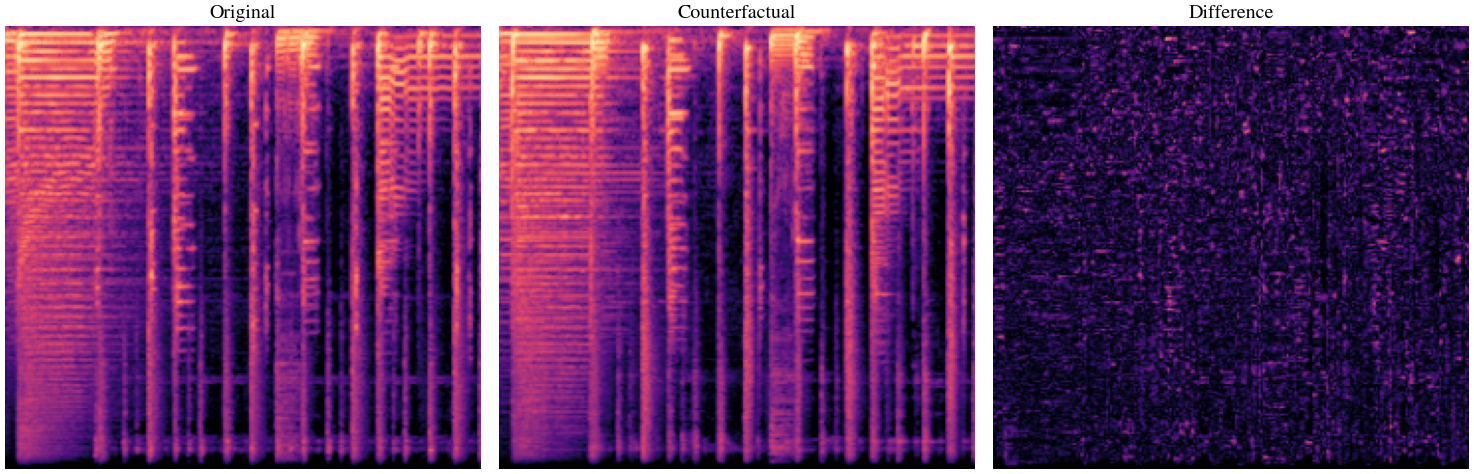

Saved C:\Users\dualp\Documents\MVA\XAI\Projet\mva-DiME\report\figures\guitar_removal_hq_step0_sample0_comparison.pdf


: 

In [ ]:
def plot_spectrogram_comparison(exp_name, step=0, sample_idx=0):
    base_dir = experiment_run_dir(exp_name, step)
    orig_path = base_dir / "original_spec" / f"{sample_idx:06d}.png"
    cf_path = base_dir / "cf_spec" / f"{sample_idx:06d}.png"
    diff_path = base_dir / "diff_spec" / f"{sample_idx:06d}.png"
    for p in (orig_path, cf_path, diff_path):
        if not p.is_file():
            raise FileNotFoundError(p)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, path, title in zip(
        axes,
        [orig_path, cf_path, diff_path],
        ["Original", "Counterfactual", "Difference"],
    ):
        img = PIL.Image.open(path)
        ax.imshow(img, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    out = REPORT_DIR / f"{exp_name}_step{step}_sample{sample_idx}_comparison.pdf"
    plt.savefig(out, backend="pgf")
    plt.show()
    print("Saved", out)


# Example (current repo: guitar_removal_hq, steps 0–5):
plot_spectrogram_comparison("guitar_removal_hq", step=0, sample_idx=0)

## Figure 2: Diversity Assessment

Compare multiple counterfactuals for the same input (requires multiple
runs/experiments).


In [7]:
def plot_diversity(exp_names, step=0, sample_idx=0):
    if len(exp_names) < 1:
        raise ValueError("exp_names must be non-empty")
    n = len(exp_names)
    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))

    orig_path = (
        experiment_run_dir(exp_names[0], step)
        / "original_spec"
        / f"{sample_idx:06d}.png"
    )
    axes[0].imshow(
        PIL.Image.open(orig_path), aspect="auto", origin="lower", cmap="magma"
    )
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, exp in enumerate(exp_names):
        cf_path = experiment_run_dir(exp, step) / "cf_spec" / f"{sample_idx:06d}.png"
        axes[i + 1].imshow(
            PIL.Image.open(cf_path), aspect="auto", origin="lower", cmap="magma"
        )
        axes[i + 1].set_title(f"CF {i + 1} ({exp})")
        axes[i + 1].axis("off")

    plt.tight_layout()
    out = REPORT_DIR / f"diversity_sample{sample_idx}.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved", out)

## Figure 3: Generation Pipeline

Visualize intermediate denoising steps (requires --save_intermediate True).


In [4]:
def plot_pipeline(exp_name, step=0, sample_idx=0):
    inter_dir = (
        experiment_run_dir(exp_name, step) / "intermediate" / f"{sample_idx:06d}"
    )
    if not inter_dir.is_dir():
        print("Intermediate steps not found. Run with --save_intermediate True")
        return

    files = sorted(
        f for f in inter_dir.iterdir() if f.suffix.lower() in (".png", ".jpg", ".jpeg")
    )
    if not files:
        print("No images in", inter_dir)
        return

    indices = np.linspace(0, len(files) - 1, min(5, len(files)), dtype=int)

    fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        img = PIL.Image.open(files[idx])
        ax.imshow(img, aspect="auto", origin="lower", cmap="magma")
        ax.set_title(files[idx].name)
        ax.axis("off")

    plt.tight_layout()
    out = REPORT_DIR / f"pipeline_{exp_name}_step{step}_sample{sample_idx}.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print("Saved", out)

## Classifier Testing on Breakbeat Dataset

Test the OpenMIC-trained classifier on the `teticio/audio-diffusion-breaks-256`
dataset to see what it detects in the baseline music.


In [5]:
import base64
import io

import soundfile as sf
import torch
from datasets import load_dataset
from IPython.display import HTML, display

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from audio.audio_classifier import build_classifier
from audio.spectrogram_utils import tensor_to_audio, image_to_tensor
from dense_audio_classifier.data.mel_openmic_datamodule import INSTRUMENTS


def test_classifier_on_breaks(n_samples=5):
    # 1. Load Classifier
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    classifier = build_classifier(
        checkpoint_path="",
        wandb_artifact="mva-altegrad-challenge/xai-dime/train_dense_classifier_openmic:v0",
    ).to(device)
    classifier.eval()

    # 2. Load Dataset
    ds = load_dataset("teticio/audio-diffusion-breaks-256", split="train")
    subset = ds.shuffle(seed=42).select(range(n_samples))

    instrument_names = [inst.replace("_", " ").title() for inst in INSTRUMENTS]

    rows = []
    with torch.no_grad():
        for i, sample in enumerate(subset):
            img = sample["image"]
            spec_tensor = (
                image_to_tensor(img).to(device).unsqueeze(0)
            )  # [1, 1, 256, 256]

            logits = classifier(spec_tensor)
            probs = torch.sigmoid(logits)[0].cpu().numpy()

            # Audio reconstruction
            audio = tensor_to_audio(spec_tensor[0])
            buf = io.BytesIO()
            sf.write(buf, audio, 22050, format="WAV")
            b64 = base64.b64encode(buf.getvalue()).decode()

            pred_labels = [instrument_names[j] for j, p in enumerate(probs) if p > 0.5]
            pred_str = ", ".join(pred_labels) if pred_labels else "None"

            rows.append(
                f"<tr><td>{i}</td><td><audio controls src='data:audio/wav;base64,{b64}'></audio></td><td>{pred_str}</td></tr>"
            )

    html = (
        "<table border='1'><tr><th>#</th><th>Audio</th><th>Predicted</th></tr>"
        + "".join(rows)
        + "</table>"
    )
    display(HTML(html))


test_classifier_on_breaks(5)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\dualp\_netrc.
wandb: Downloading large artifact 'train_dense_classifier_openmic:v0', 80.70MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.9 (87.5MB/s)


  Auto-detected num_classes=20 from checkpoint


#,Audio,Predicted
0,,"Cymbals, Drums, Guitar, Violin, Voice"
1,,"Cymbals, Flute, Piano, Synthesizer, Violin"
2,,"Cymbals, Drums, Saxophone, Synthesizer, Trombone, Trumpet, Voice"
3,,"Cymbals, Synthesizer, Voice"
4,,"Cymbals, Drums, Guitar, Voice"


## Table 1: Main Results Table


In [ ]:
def compute_snr_db(x, y, eps=1e-8):
    noise = y - x
    p_signal = np.mean(x**2)
    p_noise = np.mean(noise**2)
    return 10 * np.log10((p_signal + eps) / (p_noise + eps))


def compute_lsd(x, y, sr=22050, n_fft=1024, hop_length=512, eps=1e-8):
    sx = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length)) + eps
    sy = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) + eps
    lx = 20 * np.log10(sx)
    ly = 20 * np.log10(sy)
    return np.mean(np.sqrt(np.mean((lx - ly) ** 2, axis=0)))


def collect_all_metrics(exp_name, step=0):
    step_dir = experiment_run_dir(exp_name, step)
    info_dir = step_dir / "info"
    if not info_dir.is_dir():
        raise FileNotFoundError(info_dir)

    flipped, l1s, mnac = [], [], []
    for path in sorted(info_dir.glob("*.json")):
        with open(path, "r") as j:
            d = json.load(j)
        flipped.append(d["flipped"])
        l1s.append(d["l1"])
        pb, pa = np.array(d["all_probs_before"]), np.array(d["all_probs_after"])
        mask = np.ones_like(pb, dtype=bool)
        mask[d["target_class"]] = False
        mnac.append(((pb[mask] > 0.5) != (pa[mask] > 0.5)).sum())

    snrs, lsds = [], []
    orig_wav = step_dir / "original_wav"
    cf_wav = step_dir / "cf_wav"
    if orig_wav.is_dir() and cf_wav.is_dir():
        for wav_path in sorted(orig_wav.glob("*.wav")):
            cf_path = cf_wav / wav_path.name
            if not cf_path.is_file():
                continue
            x, sr0 = librosa.load(wav_path, sr=None, mono=True)
            y, sr1 = librosa.load(cf_path, sr=None, mono=True)
            if sr0 != sr1:
                y = librosa.resample(y, orig_sr=sr1, target_sr=sr0)
            n = min(len(x), len(y))
            x, y = x[:n], y[:n]
            snrs.append(compute_snr_db(x, y))
            lsds.append(compute_lsd(x, y, sr=sr0))

    row = {
        "Flip Ratio (%)": 100 * float(np.mean(flipped)),
        "L1 Prox": float(np.mean(l1s)),
        "MNAC": float(np.mean(mnac)),
    }
    if snrs:
        row["SNR (dB)"] = float(np.mean(snrs))
        row["LSD"] = float(np.mean(lsds))
    else:
        row["SNR (dB)"] = np.nan
        row["LSD"] = np.nan
    return row


# Experiments under audio/results (prioritize guitar_removal_hq if present)
preferred = ("guitar_removal_hq",)
all_exps = [e for e in preferred if (RESULTS_ROOT / e).is_dir()]
if not all_exps:
    all_exps = list_experiments()

rows = []
idx = []
for exp in all_exps:
    for s in list_steps(exp):
        rows.append(collect_all_metrics(exp, s))
        idx.append((exp, s))

if not rows:
    df = pd.DataFrame()
    print("No experiment data found under", RESULTS_ROOT)
else:
    df = pd.DataFrame(
        rows,
        index=pd.MultiIndex.from_tuples(idx, names=["experiment", "step"]),
    )
    tex_path = REPORT_DIR / "main_results.tex"
    df.to_latex(tex_path, escape=True)
    print("Wrote", tex_path)

display(df)


Wrote C:\Users\dualp\Documents\MVA\XAI\Projet\mva-DiME\report\figures\main_results.tex


Flip Ratio (%)   L1 Prox   MNAC  SNR (dB)       LSD
experiment        step                                                     
guitar_removal_hq 0              100.0  0.110702  1.800 -2.950137  9.364269
                  1               62.5  0.106687  3.000 -3.073757  9.210129
                  2              100.0  0.107320  2.375 -2.981012  9.261023
                  3              100.0  0.106692  2.125 -2.908162  9.258429
                  4              100.0  0.105072  1.875 -3.239836  9.221994
                  5              100.0  0.104598  1.375 -3.153058  9.172865